In [25]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import pathlib
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix

# Data Preparation

In [26]:
data_dir = pathlib.Path('../Datasets/6_Garbage_Class')

In [27]:
print(data_dir)

..\Datasets\6_Garbage_Class


..\Datasets\6_Garbage_Class\glass\glass1.jpg


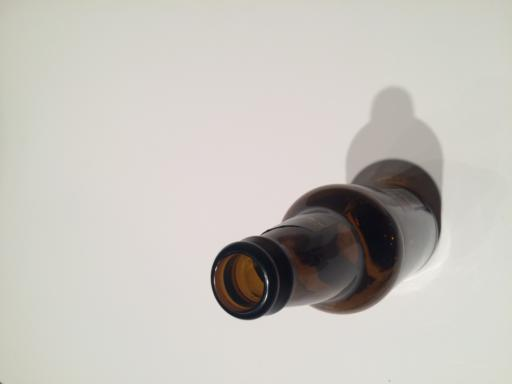

In [28]:
glass = list(data_dir.glob('glass/*'))
print(glass[0])
PIL.Image.open(str(glass[0]))

In [29]:
"""img_height, img_width = 180, 180
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    label_mode='categorical',
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)"""

'img_height, img_width = 180, 180\nbatch_size = 32\n\ntrain_ds = tf.keras.preprocessing.image_dataset_from_directory(\n    data_dir,\n    validation_split=0.2,\n    subset="training",\n    seed=123,\n    label_mode=\'categorical\',\n    image_size=(img_height, img_width),\n    batch_size=batch_size\n)\n\nclass_names = train_ds.class_names\nprint(class_names)'

In [30]:
"""val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    label_mode='categorical',
    image_size=(img_height, img_width),
    batch_size=batch_size
)"""

'val_ds = tf.keras.preprocessing.image_dataset_from_directory(\n    data_dir,\n    validation_split=0.2,\n    subset="validation",\n    seed=123,\n    label_mode=\'categorical\',\n    image_size=(img_height, img_width),\n    batch_size=batch_size\n)'

In [31]:
train_path = "../Datasets/6_Train"
val_path = "../Datasets/6_Val"
test_path = "../Datasets/6_Test"

IMAGE_SIZE = (180, 180)
BATCH_SIZE = 32
SEED = 123

train_ds = image_dataset_from_directory(
  train_path,
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE,
  seed=SEED,
  label_mode='categorical'
)

val_ds = image_dataset_from_directory(
  val_path,
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE,
  seed=SEED,
  label_mode='categorical'
)

test_ds = image_dataset_from_directory(
    test_path,
    image_size=IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    shuffle=False,
    label_mode = None
)

test_ds_with_labels = image_dataset_from_directory(
    test_path,
    image_size=IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    shuffle=False,
    label_mode='categorical'
)

# For model performance evaluation
y_test = np.concatenate([y for x, y in test_ds_with_labels])

class_names = train_ds.class_names

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

"""train_ds = train_ds.apply(
  tf.data.experimental.ignore_errors()
)"""


Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 1 classes.
Found 384 files belonging to 6 classes.


'train_ds = train_ds.apply(\n  tf.data.experimental.ignore_errors()\n)'

# Model Training

In [32]:
resnet_model = Sequential()

pretrained_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(180,180,3),
    pooling='avg',
    classes=len(class_names),
    weights='imagenet'
)

for layer in pretrained_model.layers:
    layer.trainable=False

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dense(len(class_names), activation='softmax'))

In [33]:
resnet_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 flatten_1 (Flatten)         (None, 2048)              0         
                                                                 
 dense_2 (Dense)             (None, 512)               1049088   
                                                                 
 dense_3 (Dense)             (None, 6)                 3078      
                                                                 
Total params: 24,639,878
Trainable params: 1,052,166
Non-trainable params: 23,587,712
_________________________________________________________________


In [34]:
resnet_model.compile(
    optimizer=Adam(lr=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\jstha\miniconda3\envs\Tensorflow\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [35]:
epochs = 10
history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
56/56 [==============================] - 9s 101ms/step - loss: 0.9819 - accuracy: 0.6835 - val_loss: 0.7068 - val_accuracy: 0.7639
Epoch 2/10
56/56 [==============================] - 4s 69ms/step - loss: 0.3394 - accuracy: 0.8788 - val_loss: 0.5245 - val_accuracy: 0.7984
Epoch 3/10
56/56 [==============================] - 4s 63ms/step - loss: 0.1954 - accuracy: 0.9366 - val_loss: 0.5016 - val_accuracy: 0.8355
Epoch 4/10
56/56 [==============================] - 4s 64ms/step - loss: 0.1156 - accuracy: 0.9694 - val_loss: 0.5197 - val_accuracy: 0.8302
Epoch 5/10
56/56 [==============================] - 4s 63ms/step - loss: 0.0624 - accuracy: 0.9909 - val_loss: 0.4916 - val_accuracy: 0.8435
Epoch 6/10
56/56 [==============================] - 4s 64ms/step - loss: 0.0727 - accuracy: 0.9836 - val_loss: 0.8341 - val_accuracy: 0.7905
Epoch 7/10
56/56 [==============================] - 4s 62ms/step - loss: 0.0620 - accuracy: 0.9841 - val_loss: 0.4982 - val_accuracy: 0.8302
Epoch 8/10
5

Predictions

In [36]:
import cv2

image = cv2.imread(str(glass[0]))
image_resized = cv2.resize(image, IMAGE_SIZE)
image = np.expand_dims(image_resized, axis=0)
print(image.shape)


(1, 180, 180, 3)


In [37]:
pred = resnet_model.predict(test_ds)

12/12 [==============================] - 1s 51ms/step


In [38]:
y_pred = np.argmax(pred, axis=1)

In [39]:
y_test = np.concatenate([y for x, y in test_ds_with_labels])
y_test_labels = np.argmax(y_test, axis=1)

In [40]:
cm = confusion_matrix(y_test_labels, y_pred, labels=np.arange(len(class_names)))

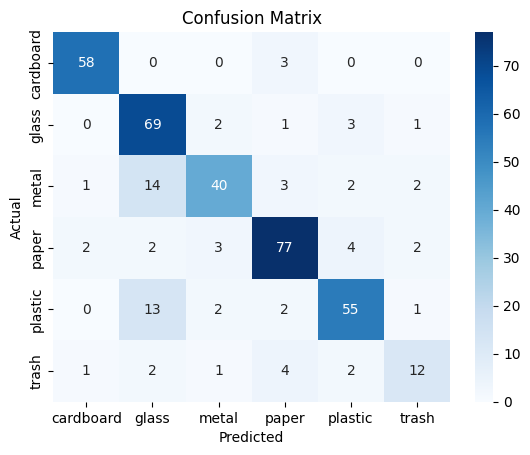

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f"Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()